In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt

In [0]:
spark = SparkSession.builder.appName("Customer_Clustering").getOrCreate()

In [0]:
df = spark.read.csv(
    "/Volumes/workspace/default/assignment_data/adult.csv",
    header=True,
    inferSchema=True
)
display(df.limit(5))

age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [0]:
df.printSchema()
print("Rows :", df.count())
print("Columns :", len(df.columns))

root
 |-- age: integer (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: integer (nullable = true)
 |-- education: string (nullable = true)
 |-- education.num: integer (nullable = true)
 |-- marital.status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital.gain: integer (nullable = true)
 |-- capital.loss: integer (nullable = true)
 |-- hours.per.week: integer (nullable = true)
 |-- native.country: string (nullable = true)
 |-- income: string (nullable = true)

Rows : 32561
Columns : 15


## Data Preprocessing

In [0]:
# replacing the dot in the column names
df = df.toDF(*[
    c.replace(".", "_")
     .replace("-", "_")
     .replace(" ", "_")
    for c in df.columns
])
print(df.columns)

['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [0]:
# checking the missing values 
 
display(
    df.select(
        count(when(col("workclass") == "?", True)).alias("workclass_missing"),
        count(when(col("occupation") == "?", True)).alias("occupation_missing"),
        count(when(col("native_country") == "?", True)).alias("native_country_missing")
    )
)

workclass_missing,occupation_missing,native_country_missing
1836,1843,583


In [0]:
# Removing the missing values

df = df.filter(col("workclass") != "?")
df = df.filter(col("occupation") != "?")
df = df.filter(col("native_country") != "?")

In [0]:
# verifying it 

display(
    df.select(
        count(when(col("workclass") == "?", True)).alias("workclass_missing"),
        count(when(col("occupation") == "?", True)).alias("occupation_missing"),
        count(when(col("native_country") == "?", True)).alias("native_country_missing")
    )
)

workclass_missing,occupation_missing,native_country_missing
0,0,0


In [0]:
# Remove Duplicates rows if exists

print("Rows Before:", df.count())
df = df.dropDuplicates()
print("Rows After:", df.count())

Rows Before: 30162
Rows After: 30139


## Feature Engineering

In [0]:
# Categorical columns 

categorical_cols = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country"]

for column in categorical_cols:

    indexer = StringIndexer(
        inputCol=column,
        outputCol=column + "_index",
        handleInvalid="keep"
    )

    df = indexer.fit(df).transform(df)

## Feature Scaling

In [0]:
feature_columns = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "workclass_index",
    "education_index",
    "marital_status_index",
    "occupation_index",
    "relationship_index",
    "race_index",
    "sex_index",
    "native_country_index"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

df = assembler.transform(df)
display(df.limit(5).select("features"))

features
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""34.0"",""203034.0"",""13.0"",""0.0"",""2824.0"",""50.0"",""0.0"",""2.0"",""3.0"",""4.0"",""1.0"",""0.0"",""0.0"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""59.0"",""107287.0"",""6.0"",""0.0"",""2559.0"",""50.0"",""4.0"",""7.0"",""4.0"",""2.0"",""3.0"",""0.0"",""1.0"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""51.0"",""68898.0"",""11.0"",""0.0"",""2444.0"",""39.0"",""3.0"",""4.0"",""2.0"",""10.0"",""1.0"",""0.0"",""0.0"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""55.0"",""124137.0"",""15.0"",""0.0"",""2415.0"",""35.0"",""4.0"",""9.0"",""0.0"",""0.0"",""0.0"",""0.0"",""0.0"",""26.0""]}"
"{""type"":""0"",""size"":""14"",""indices"":[""0"",""1"",""2"",""4"",""5"",""6"",""7""],""values"":[""41.0"",""297248.0"",""15.0"",""2415.0"",""45.0"",""2.0"",""9.0""]}"


## Standardize the feature

In [0]:
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=False
)

scaler_model = scaler.fit(df)
df = scaler_model.transform(df)
display(df.select("scaled_features").limit(5))

scaled_features
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""2.589208519643689"",""1.9216036671611085"",""5.100562588787359"",""0.0"",""6.982403869162832"",""4.1740571348126725"",""0.0"",""0.6328610656755982"",""2.767694777640461"",""1.3499447036258276"",""0.7378004508775404"",""0.0"",""0.0"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""4.493038313499342"",""1.0154116681871699"",""2.3541058102095502"",""0.0"",""6.327185375774676"",""4.1740571348126725"",""3.0797274219575552"",""2.2150137298645936"",""3.6902597035206144"",""0.6749723518129138"",""2.213401352632621"",""0.0"",""2.136263471386716"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""3.8838127794655337"",""0.6520811758624963"",""4.3158606520508425"",""0.0"",""6.042845274870382"",""3.2557645651538847"",""2.3097955664681664"",""1.2657221313511964"",""1.8451298517603072"",""3.374861759064569"",""0.7378004508775404"",""0.0"",""0.0"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""4.1884255464824385"",""1.1748875283468707"",""5.885264525523876"",""0.0"",""5.971142118990169"",""2.9218399943688707"",""3.0797274219575552"",""2.847874795540192"",""0.0"",""0.0"",""0.0"",""0.0"",""0.0"",""6.297737361532431""]}"
"{""type"":""0"",""size"":""14"",""indices"":[""0"",""1"",""2"",""4"",""5"",""6"",""7""],""values"":[""3.1222808619232723"",""2.813286675415473"",""5.885264525523876"",""5.971142118990169"",""3.7566514213314055"",""1.5398637109787776"",""2.847874795540192""]}"


## Find Optimal K (Elbow Method)

In [0]:
cost = []

for k in range(2,11):

    kmeans = KMeans(
        featuresCol="scaled_features",
        k=k,
        seed=42
    )

    model = kmeans.fit(df)

    cost.append(model.summary.trainingCost)

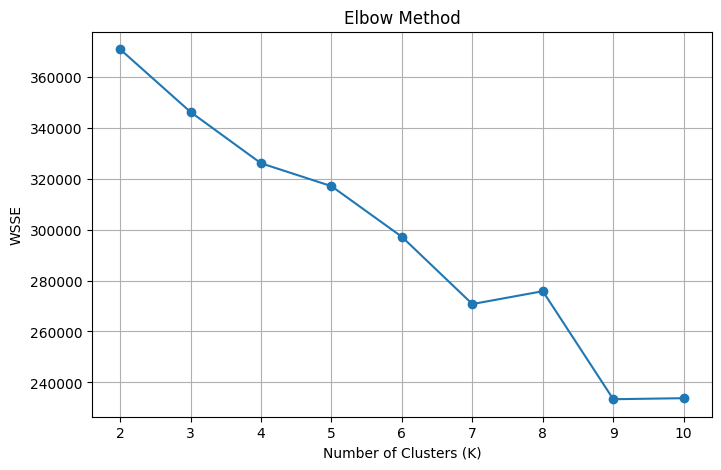

In [0]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), cost, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WSSE")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [0]:
# we will choose k = 6 that is pretty stable than the other bends (both balanced and showing the significant drop)

## K-Means Clustering

In [0]:
kmeans = KMeans(
    featuresCol="scaled_features",
    predictionCol="cluster",
    k=6,
    seed=42
)

model = kmeans.fit(df)

df = model.transform(df)

## View Cluster Assignment

In [0]:
display(
    df.select("cluster").limit(10)
)

cluster
2
3
0
1
2
2
3
5
3
5


## Cluster Distribution

In [0]:
display(
    df.groupBy("cluster")
      .count()
      .orderBy("cluster")
)

cluster,count
0,4762
1,1546
2,7396
3,8500
4,2637
5,5298


## View Cluster Centers

In [0]:
centers = model.clusterCenters()

for i, center in enumerate(centers):
    print(f"\nCluster {i}")
    print(center)


Cluster 0
[3.11782366 1.57916921 3.83394154 0.06609915 0.1647109  3.76447615
 0.4778998  0.3304033  0.32455992 2.52963498 0.25202931 0.16015341
 0.02669773 0.0308767 ]

Cluster 1
[2.79679212 1.67754434 3.99799072 0.08846512 0.18553466 3.38308137
 0.44739283 0.88413216 0.91009783 1.26068678 1.11334753 2.99077286
 0.72446001 3.24270191]

Cluster 2
[3.4095286  1.61745862 4.64305816 0.42934179 0.48493255 3.84244303
 0.90183999 0.84919753 0.20090418 0.5241128  0.13138366 0.09741524
 0.03432096 0.04238126]

Cluster 3
[2.81880645 1.71739683 4.100982   0.06445894 0.14628859 3.07194098
 0.45338619 0.49989767 1.43032312 1.15708979 1.70833457 0.28860404
 2.08974643 0.04370578]

Cluster 4
[3.0414329  1.94853815 2.03595132 0.03012294 0.12232909 3.12116543
 0.2414045  2.90364508 0.93652204 1.79120405 1.0090342  0.27660724
 0.54456943 0.23635754]

Cluster 5
[2.22862599 2.33470715 3.90755193 0.03499183 0.0674408  3.21752296
 0.1724518  0.36071993 0.97682309 1.13129078 1.09155583 0.21072259
 0.0334492